# Projeto Avaliativo — Machine Learning e Visão Computacional

## Previsão de Risco de Crédito

O objetivo deste projeto é desenvolver um pipeline preditivo capaz de identificar
clientes com risco de inadimplência.

A variável alvo utilizada será `loan_status`, onde:

- `0` = cliente sem inadimplência
- `1` = cliente inadimplente

O projeto será dividido em etapas de análise exploratória, tratamento de dados,
engenharia de atributos, preparação dos dados, treinamento dos modelos KNN e
Árvore de Decisão e avaliação dos resultados.

# 1. Preparação do Ambiente

## 1.1 Importação das Bibliotecas

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

print("Bibliotecas importadas com sucesso!")

Bibliotecas importadas com sucesso!


## 1.2 Definição do Diretório do Projeto

In [13]:
os.chdir(r"C:\Users\Alisson\Desktop\Alisson\sctec\Projeto-risco-credito")

## 1.3 Carregamento da Base de Dados

In [14]:
df = pd.read_csv("data/credit_risk_dataset.csv")

df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


# 2. Análise Exploratória de Dados (EDA)

Nesta etapa serão analisadas as dimensões da base, os tipos das variáveis, estatísticas descritivas, valores ausentes, distribuição da variável alvo e possíveis outliers.

## 2.1 Dimensões da Base

In [15]:
print("Linhas:", df.shape[0])
print("Colunas:", df.shape[1])

Linhas: 32581
Colunas: 12


## 2.2 Tipos de Dados e Valores Não Nulos

In [16]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  str    
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  str    
 5   loan_grade                  32581 non-null  str    
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  str    
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), str(4)
memory usage: 3.0 MB


## 2.3 Estatísticas Descritivas

In [17]:
df.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


## 2.4 Análise de Valores Ausentes

Nesta etapa serão identificadas as colunas que possuem valores nulos e a quantidade de registros ausentes em cada uma delas.

A análise dos valores ausentes é importante para definir posteriormente a estratégia de imputação mais adequada, utilizando média ou mediana conforme a distribuição dos dados e a presença de outliers.

In [20]:
valores_nulos = df.isnull().sum()

valores_nulos[valores_nulos > 0]

person_emp_length     895
loan_int_rate        3116
dtype: int64

In [21]:
percentual_nulos = (df.isnull().sum() / len(df)) * 100

percentual_nulos[percentual_nulos > 0]

person_emp_length    2.747000
loan_int_rate        9.563856
dtype: float64

### Análise dos Valores Ausentes

Foram identificados valores ausentes em duas variáveis:

- `person_emp_length`: 895 valores ausentes, aproximadamente 2,75% da base.
- `loan_int_rate`: 3.116 valores ausentes, aproximadamente 9,56% da base.

Esses valores serão analisados posteriormente para definir a técnica de imputação mais adequada, considerando a distribuição dos dados e a influência de possíveis outliers.

## 2.5 Distribuição da Variável Alvo

A variável alvo do projeto é `loan_status`, onde:

- `0` representa clientes adimplentes.
- `1` representa clientes inadimplentes.

Nesta etapa será analisada a proporção entre as classes para verificar a existência de desbalanceamento na base.

In [22]:
contagem_classes = df["loan_status"].value_counts()
percentual_classes = df["loan_status"].value_counts(normalize=True) * 100

print("Quantidade por classe:")
display(contagem_classes)

print("\nPercentual por classe:")
display(percentual_classes)

Quantidade por classe:


loan_status
0    25473
1     7108
Name: count, dtype: int64


Percentual por classe:


loan_status
0    78.183604
1    21.816396
Name: proportion, dtype: float64

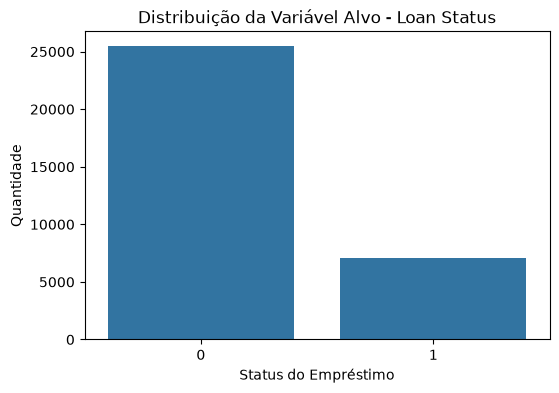

In [23]:
plt.figure(figsize=(6, 4))

sns.countplot(data=df, x="loan_status")

plt.title("Distribuição da Variável Alvo - Loan Status")
plt.xlabel("Status do Empréstimo")
plt.ylabel("Quantidade")

plt.show()

### Análise da Variável Alvo

A variável `loan_status` apresenta desbalanceamento entre as classes.

A classe `0`, referente aos clientes adimplentes, possui 25.473 registros e representa aproximadamente 78,18% da base.

A classe `1`, referente aos clientes inadimplentes, possui 7.108 registros e representa aproximadamente 21,82% da base.

Essa diferença evidencia o desbalanceamento da variável alvo. Na etapa de preparação dos dados, será aplicada uma técnica de balanceamento apenas sobre o conjunto de treino, evitando vazamento de dados para o conjunto de teste.

## 2.6 Análise de Outliers

Nesta etapa serão analisados possíveis valores discrepantes nas variáveis numéricas.

A identificação de outliers é especialmente importante porque o modelo KNN é sensível a valores extremos, já que utiliza medidas de distância entre os registros. Já a Árvore de Decisão tende a ser mais robusta a esse tipo de situação.

Por isso, os valores discrepantes não serão removidos automaticamente. Primeiro será avaliado se representam observações plausíveis ou inconsistências nos dados.

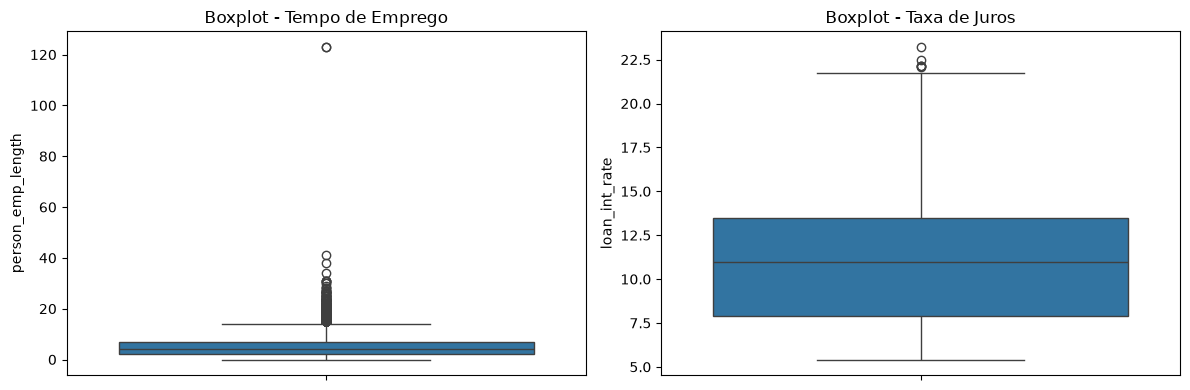

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.boxplot(y=df["person_emp_length"], ax=axes[0])
axes[0].set_title("Boxplot - Tempo de Emprego")

sns.boxplot(y=df["loan_int_rate"], ax=axes[1])
axes[1].set_title("Boxplot - Taxa de Juros")

plt.tight_layout()
plt.show()

In [25]:
df.sort_values("person_emp_length", ascending=False)[
    ["person_age", "person_emp_length"]
].head(15)

,person_age,person_emp_length
210,21,123.0
0,22,123.0
32355,78,41.0
32515,53,38.0
32428,58,34.0
31866,47,31.0
30914,48,31.0
31867,46,31.0
32263,46,31.0
32539,61,30.0


### Análise dos Outliers

A variável `person_emp_length` apresentou diversos valores acima do limite superior do boxplot.

Ao analisar os maiores registros, foram encontrados dois casos em que o tempo de emprego é igual a 123 anos para clientes de 21 e 22 anos. Esses valores são logicamente impossíveis e indicam inconsistência nos dados.

Por outro lado, outros valores elevados de tempo de emprego, como 30, 31, 38 e 41 anos, podem ser plausíveis dependendo da idade do cliente e, por isso, não serão removidos automaticamente.

Na variável `loan_int_rate`, foram observados alguns valores acima do limite superior do boxplot, porém eles permanecem dentro de uma faixa possível para taxas de juros. Portanto, esses registros serão mantidos.

As inconsistências identificadas em `person_emp_length` serão tratadas na etapa de limpeza dos dados.